In [40]:
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
warnings.filterwarnings('ignore')

In [41]:
df = pd.read_csv("../data/raw/index_1.csv")
df["date"] = pd.to_datetime(df["date"])

date_range = pd.date_range(start=df["date"].min(), end=df["date"].max())
complete_dates = pd.DataFrame(date_range, columns=["date"])
df_by_date = df.groupby("date").agg({"money": ["count"]}).reset_index()
df_by_date.columns = ["date", "cups"]
df_complete = pd.merge(complete_dates, df_by_date, on="date", how="left")
df_complete.fillna(0, inplace=True)

In [42]:
test_size = 7

train_size = df_complete.shape[0] - test_size

df_train = df_complete.iloc[:train_size]
df_test = df_complete.iloc[train_size:]

metrics = []

(0.0, 27.3)

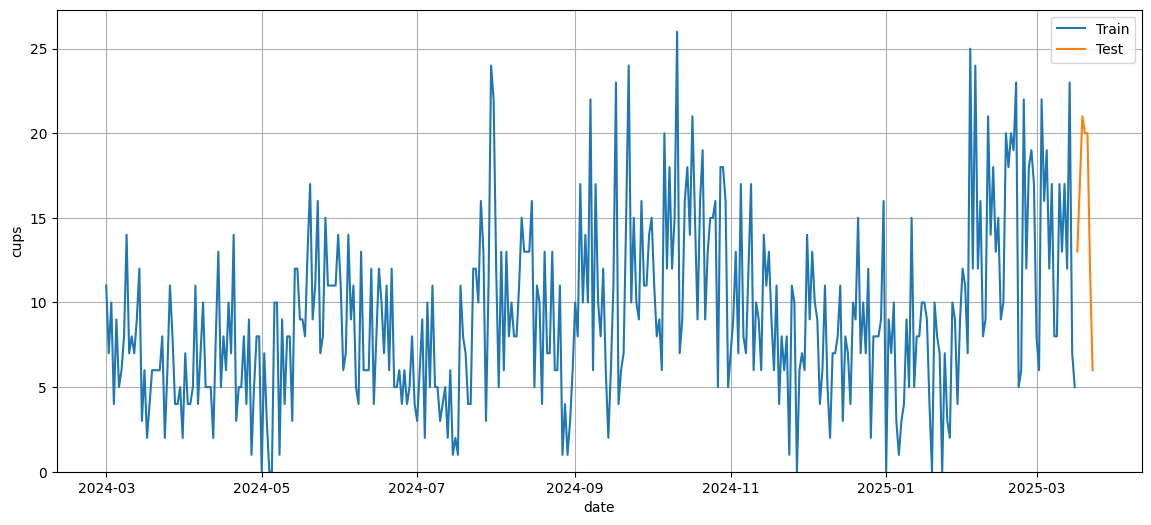

In [43]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_train, y="cups", x="date", label="Train")
sns.lineplot(data=df_test, y="cups", x="date", label="Test")
plt.grid()
plt.ylim(0)

In [44]:
p, d, q = 5, 0, 5
model = ARIMA(df_train['cups'], order=(p, d, q))
model_fit = model.fit()
test_predictions = model_fit.forecast(steps=len(df_test)).values
df_test["arima_pred"] = test_predictions

(0.0, 27.3)

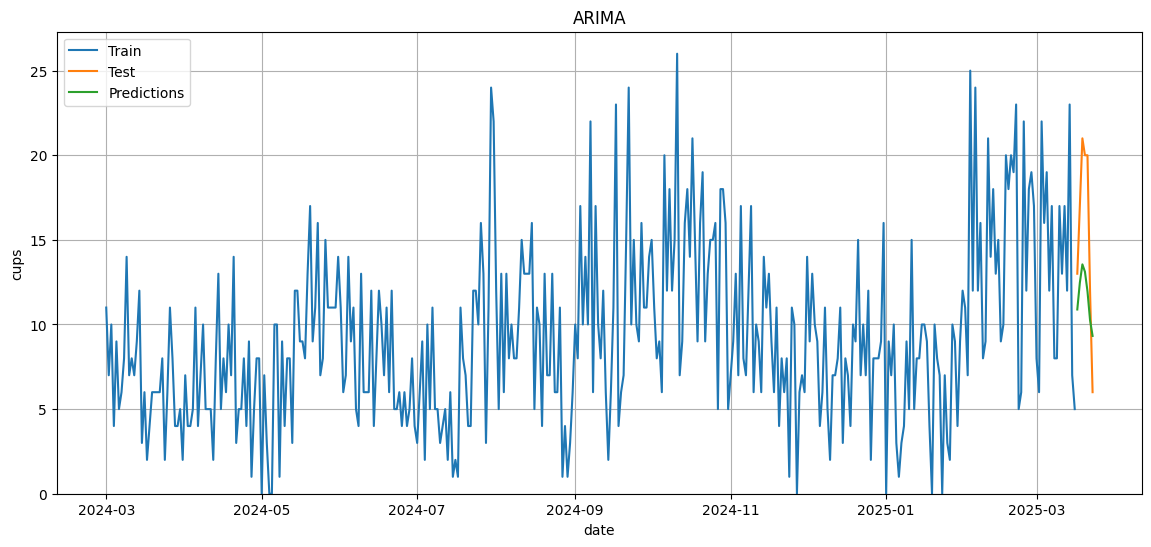

In [45]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_train, y="cups", x="date", label="Train")
sns.lineplot(data=df_test, y="cups", x="date", label="Test")
sns.lineplot(data=df_test, y="arima_pred", x="date", label="Predictions")
plt.title('ARIMA')
plt.grid()
plt.ylim(0)

In [46]:
df_test

,date,cups,arima_pred
381,2025-03-17,13.0,10.886709
382,2025-03-18,17.0,12.466610
383,2025-03-19,21.0,13.553121
384,2025-03-20,20.0,13.116972
385,2025-03-21,20.0,11.956763
386,2025-03-22,12.0,10.266114
387,2025-03-23,6.0,9.325843


In [47]:
mae = mean_absolute_error(df_test["cups"], test_predictions)
metrics.append({"model": "ARIMA", "mae": mae})
print(f'Mean Absolute Error: {mae}')

Mean Absolute Error: 4.868507621097216


In [48]:
p, d, q = 5, 0, 5
P, D, Q, m = 1, 1, 1, 7
model = SARIMAX(df_train['cups'], order=(p, d, q), seasonal_order=(P, D, Q, m))
model_fit = model.fit()

In [49]:
model = auto_arima(
    df_train['cups'],
    seasonal=False, 
    trace=True, 
    error_action='ignore', 
    suppress_warnings=True,
)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=2240.755, Time=0.39 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2440.275, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=2332.681, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=2235.009, Time=0.07 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2438.278, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=2236.915, Time=0.11 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=2236.914, Time=0.10 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=2238.763, Time=0.31 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=2233.127, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=2235.026, Time=0.14 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=2235.025, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=2330.684, Time=0.02 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=2236.876, Time=0.17 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0]          
Total fit time: 1.503 seconds


(0.0, 27.3)

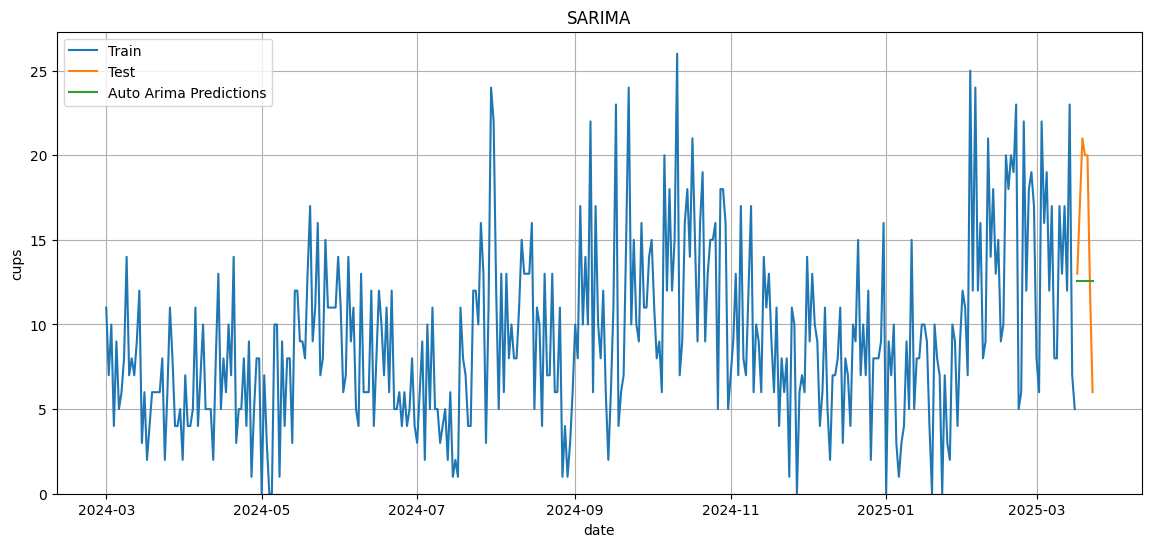

In [50]:
test_predictions = model.predict(n_periods=len(df_test)).values
df_test["auto_arima_pred"] = test_predictions
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_train, y="cups", x="date", label="Train")
sns.lineplot(data=df_test, y="cups", x="date", label="Test")
sns.lineplot(data=df_test, y="auto_arima_pred", x="date", label="Auto Arima Predictions")
plt.title('SARIMA')
plt.grid()
plt.ylim(0)

In [51]:
mae = mean_absolute_error(df_test["cups"], test_predictions)
metrics.append({"model": "SARIMA", "mae": mae})
print(f'Mean Absolute Error: {mae}')

Mean Absolute Error: 5.036283787472927


(0.0, 27.3)

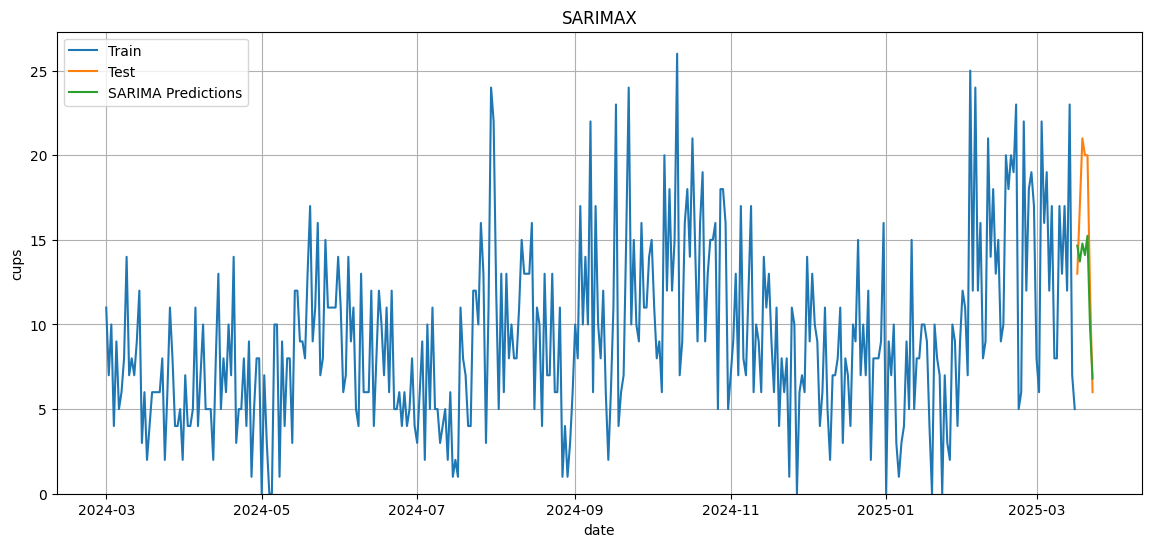

In [52]:
test_predictions = model_fit.forecast(steps=len(df_test)).values
df_test["sarimax_pred"] = test_predictions
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_train, y="cups", x="date", label="Train")
sns.lineplot(data=df_test, y="cups", x="date", label="Test")
sns.lineplot(data=df_test, y="sarimax_pred", x="date", label="SARIMA Predictions")
plt.title('SARIMAX')
plt.grid()
plt.ylim(0)

In [53]:
mae = mean_absolute_error(df_test["cups"], test_predictions)
metrics.append({"model": "SARIMAX", "mae": mae})
print(f'Mean Absolute Error: {mae}')

Mean Absolute Error: 3.5402497923739875


<Axes: xlabel='mae', ylabel='model'>

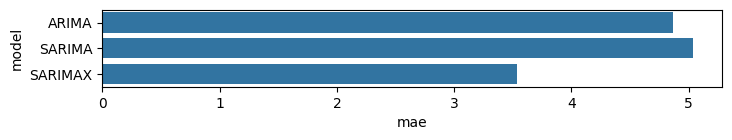

In [55]:
df_metrics = pd.DataFrame(metrics)
plt.figure(figsize=(8, 1 * df_metrics.shape[0] // 2),edgecolor='k', facecolor='w')
sns.barplot(data=df_metrics, y="model", x="mae")